## Imports

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## BASE TABELA 1620

In [2]:
from google.colab import files

uploaded = files.upload()

Saving tabela1620.csv to tabela1620 (1).csv


In [3]:
arquivo = "tabela1620.csv"

df_raw = pd.read_csv(
    arquivo,
    sep=";",
    header=None,
    skiprows=3,
    dtype=str
)

df_raw.head()

,0,1,2,3,4,5,6,7,8,9,...,73,74,75,76,77,78,79,80,81,82
0,NaN,1º trimestre 2006,2º trimestre 2006,3º trimestre 2006,4º trimestre 2006,1º trimestre 2007,2º trimestre 2007,3º trimestre 2007,4º trimestre 2007,1º trimestre 2008,...,1º trimestre 2024,2º trimestre 2024,3º trimestre 2024,4º trimestre 2024,1º trimestre 2025,2º trimestre 2025,3º trimestre 2025,4º trimestre 2025,1º trimestre 2026,2º trimestre 2026
1,NaN,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,...,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado,PIB a preços de mercado
2,Brasil,"128,18","132,13","136,72","136,37","134,84","140,77","144,75","145,43","143,14",...,"185,18","190,68","195,10","189,45","191,02","195,18","198,66","192,94","194,53","199,05"
3,Fonte: IBGE - Contas Nacionais Trimestrais,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
periodos = df_raw.iloc[0, 1:]
valores = df_raw[df_raw[0] == "Brasil"].iloc[0, 1:]

print("Quantidade de períodos:", len(periodos))
print("Quantidade de valores:", len(valores))

Quantidade de períodos: 82
Quantidade de valores: 82


In [5]:
pib_trimestral = pd.DataFrame({
    "Periodo": periodos.values,
    "PIB_indice": valores.values
})

pib_trimestral.head(8)

,Periodo,PIB_indice
0,1º trimestre 2006,"128,18"
1,2º trimestre 2006,"132,13"
2,3º trimestre 2006,"136,72"
3,4º trimestre 2006,"136,37"
4,1º trimestre 2007,"134,84"
5,2º trimestre 2007,"140,77"
6,3º trimestre 2007,"144,75"
7,4º trimestre 2007,"145,43"


In [6]:
pib_trimestral["Ano"] = (
    pib_trimestral["Periodo"]
    .str.extract(r"(\d{4})")
    .astype(int)
)

pib_trimestral.head(8)

,Periodo,PIB_indice,Ano
0,1º trimestre 2006,"128,18",2006
1,2º trimestre 2006,"132,13",2006
2,3º trimestre 2006,"136,72",2006
3,4º trimestre 2006,"136,37",2006
4,1º trimestre 2007,"134,84",2007
5,2º trimestre 2007,"140,77",2007
6,3º trimestre 2007,"144,75",2007
7,4º trimestre 2007,"145,43",2007


In [7]:
pib_trimestral["PIB_indice"] = (
    pib_trimestral["PIB_indice"]
    .str.replace(",", ".", regex=False)
    .astype(float)
)

pib_trimestral.head(8)

,Periodo,PIB_indice,Ano
0,1º trimestre 2006,128.18,2006
1,2º trimestre 2006,132.13,2006
2,3º trimestre 2006,136.72,2006
3,4º trimestre 2006,136.37,2006
4,1º trimestre 2007,134.84,2007
5,2º trimestre 2007,140.77,2007
6,3º trimestre 2007,144.75,2007
7,4º trimestre 2007,145.43,2007


In [8]:
pib_trimestral = pib_trimestral[
    pib_trimestral["Ano"].between(2006, 2025)
].copy()

pib_trimestral.tail()

,Periodo,PIB_indice,Ano
75,4º trimestre 2024,189.45,2024
76,1º trimestre 2025,191.02,2025
77,2º trimestre 2025,195.18,2025
78,3º trimestre 2025,198.66,2025
79,4º trimestre 2025,192.94,2025


In [9]:
trimestres_por_ano = pib_trimestral.groupby("Ano").size()

print(trimestres_por_ano)

Ano
2006    4
2007    4
2008    4
2009    4
2010    4
2011    4
2012    4
2013    4
2014    4
2015    4
2016    4
2017    4
2018    4
2019    4
2020    4
2021    4
2022    4
2023    4
2024    4
2025    4
dtype: int64


In [10]:
if (trimestres_por_ano == 4).all():
    print("Todos os anos possuem os 4 trimestres.")
else:
    print("Existe algum ano com quantidade diferente de 4 trimestres.")

Todos os anos possuem os 4 trimestres.


In [11]:
pib_anual = (
    pib_trimestral
    .groupby("Ano")["PIB_indice"]
    .mean()
    .reset_index()
)

pib_anual

,Ano,PIB_indice
0,2006,133.3500
1,2007,141.4475
2,2008,148.6525
3,2009,148.4675
4,2010,159.6425
5,2011,165.9850
6,2012,169.1750
7,2013,174.2600
8,2014,175.1400
9,2015,168.9275


In [12]:
pib_anual.to_csv(
    "pib_anual_2006_2025.csv",
    index=False
)

print("Arquivo salvo como: pib_anual_2006_2025.csv")

Arquivo salvo como: pib_anual_2006_2025.csv


In [13]:
from google.colab import files

files.download("pib_anual_2006_2025.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## BASE ABCR

In [14]:
uploaded = files.upload()

Saving abcr_0826.xlsx to abcr_0826 (1).xlsx


In [15]:
abcr_raw = pd.read_excel(
    "abcr_0826.xlsx",
    sheet_name="(C) Original",
    skiprows=3,
    header=None
)

abcr_raw.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,1999-01-01,117.667781,94.286208,112.442880,NaN,115.621665,94.890700,111.018130,NaN,130.072273,86.140365,114.250698,NaN,110.267077,97.993420,108.365801
1,1999-02-01,98.318947,87.925361,95.996372,NaN,95.448095,88.485682,93.902016,NaN,101.926359,83.961737,95.456605,NaN,94.939069,87.793056,93.832101
2,1999-03-01,95.978647,107.940122,98.651586,NaN,96.015216,105.960890,98.223760,NaN,91.598440,121.605998,102.405319,NaN,97.140236,104.606781,98.296856
3,1999-04-01,97.189397,98.208155,97.417051,NaN,98.430869,96.956850,98.103547,NaN,96.803426,104.235705,99.480076,NaN,95.995827,96.133878,96.017212
4,1999-05-01,96.210717,101.902630,97.482645,NaN,96.439384,100.699425,97.385372,NaN,93.308385,107.684536,98.485792,NaN,98.608305,99.795485,98.792208


In [16]:
abcr = abcr_raw[[0, 3]].copy()

abcr.columns = ["Data", "ABCR_indice"]

abcr.head(12)

,Data,ABCR_indice
0,1999-01-01,112.442880
1,1999-02-01,95.996372
2,1999-03-01,98.651586
3,1999-04-01,97.417051
4,1999-05-01,97.482645
5,1999-06-01,92.999567
6,1999-07-01,101.849706
7,1999-08-01,96.925366
8,1999-09-01,96.030711
9,1999-10-01,101.031778


In [17]:
abcr["Data"] = pd.to_datetime(abcr["Data"])

abcr["Ano"] = abcr["Data"].dt.year

abcr.head()

,Data,ABCR_indice,Ano
0,1999-01-01,112.442880,1999
1,1999-02-01,95.996372,1999
2,1999-03-01,98.651586,1999
3,1999-04-01,97.417051,1999
4,1999-05-01,97.482645,1999


In [18]:
abcr["ABCR_indice"] = pd.to_numeric(
    abcr["ABCR_indice"],
    errors="coerce"
)

abcr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Data         332 non-null    datetime64[ns]
 1   ABCR_indice  332 non-null    float64       
 2   Ano          332 non-null    int32         
dtypes: datetime64[ns](1), float64(1), int32(1)
memory usage: 6.6 KB


In [19]:
abcr = abcr[
    abcr["Ano"].between(2006, 2025)
].copy()

abcr.head()

,Data,ABCR_indice,Ano
84,2006-01-01,117.484382,2006
85,2006-02-01,100.130970,2006
86,2006-03-01,105.832032,2006
87,2006-04-01,104.449614,2006
88,2006-05-01,102.699143,2006


In [20]:
abcr.tail()

,Data,ABCR_indice,Ano
319,2025-08-01,173.101433,2025
320,2025-09-01,171.665193,2025
321,2025-10-01,178.231547,2025
322,2025-11-01,172.641473,2025
323,2025-12-01,190.121076,2025


In [21]:
meses_por_ano = abcr.groupby("Ano").size()

print(meses_por_ano)

Ano
2006    12
2007    12
2008    12
2009    12
2010    12
2011    12
2012    12
2013    12
2014    12
2015    12
2016    12
2017    12
2018    12
2019    12
2020    12
2021    12
2022    12
2023    12
2024    12
2025    12
dtype: int64


In [22]:
if (meses_por_ano == 12).all():
    print("Todos os anos possuem os 12 meses.")
else:
    print("Existe algum ano com quantidade diferente de 12 meses.")

Todos os anos possuem os 12 meses.


In [23]:
abcr_anual = (
    abcr
    .groupby("Ano")["ABCR_indice"]
    .mean()
    .reset_index()
)

abcr_anual

,Ano,ABCR_indice
0,2006,107.489722
1,2007,113.985870
2,2008,120.908694
3,2009,123.602071
4,2010,133.120557
5,2011,141.443000
6,2012,147.972044
7,2013,153.589045
8,2014,157.233207
9,2015,154.248226


In [24]:
abcr_anual.to_csv(
    "abcr_anual_2006_2025.csv",
    index=False
)

print("Arquivo salvo como: abcr_anual_2006_2025.csv")

Arquivo salvo como: abcr_anual_2006_2025.csv


In [25]:
files.download("abcr_anual_2006_2025.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## --------------------------------------

In [26]:
base_final = pd.merge(
    pib_anual,
    abcr_anual,
    on="Ano",
    how="inner"
)

base_final

,Ano,PIB_indice,ABCR_indice
0,2006,133.3500,107.489722
1,2007,141.4475,113.985870
2,2008,148.6525,120.908694
3,2009,148.4675,123.602071
4,2010,159.6425,133.120557
5,2011,165.9850,141.443000
6,2012,169.1750,147.972044
7,2013,174.2600,153.589045
8,2014,175.1400,157.233207
9,2015,168.9275,154.248226


In [27]:
print("Dimensões da base:", base_final.shape)

print("\nTipos das colunas:")
print(base_final.dtypes)

print("\nValores ausentes:")
print(base_final.isna().sum())

Dimensões da base: (20, 3)

Tipos das colunas:
Ano              int64
PIB_indice     float64
ABCR_indice    float64
dtype: object

Valores ausentes:
Ano            0
PIB_indice     0
ABCR_indice    0
dtype: int64


In [28]:
print("Anos disponíveis:")
print(base_final["Ano"].tolist())

Anos disponíveis:
[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


In [29]:
anos_esperados = list(range(2006, 2026))

if base_final["Ano"].tolist() == anos_esperados:
    print("Os 20 anos de 2006 a 2025 estão presentes e em ordem.")
else:
    print("Há alguma inconsistência nos anos.")

Os 20 anos de 2006 a 2025 estão presentes e em ordem.


In [30]:
base_apresentacao = base_final.copy()

base_apresentacao["PIB_indice"] = base_apresentacao["PIB_indice"].round(2)
base_apresentacao["ABCR_indice"] = base_apresentacao["ABCR_indice"].round(2)

base_apresentacao

,Ano,PIB_indice,ABCR_indice
0,2006,133.35,107.49
1,2007,141.45,113.99
2,2008,148.65,120.91
3,2009,148.47,123.60
4,2010,159.64,133.12
5,2011,165.98,141.44
6,2012,169.18,147.97
7,2013,174.26,153.59
8,2014,175.14,157.23
9,2015,168.93,154.25


In [31]:
base_final.to_csv(
    "base_regressao_pib_abcr_2006_2025.csv",
    index=False
)

print("Base final salva com sucesso.")

Base final salva com sucesso.


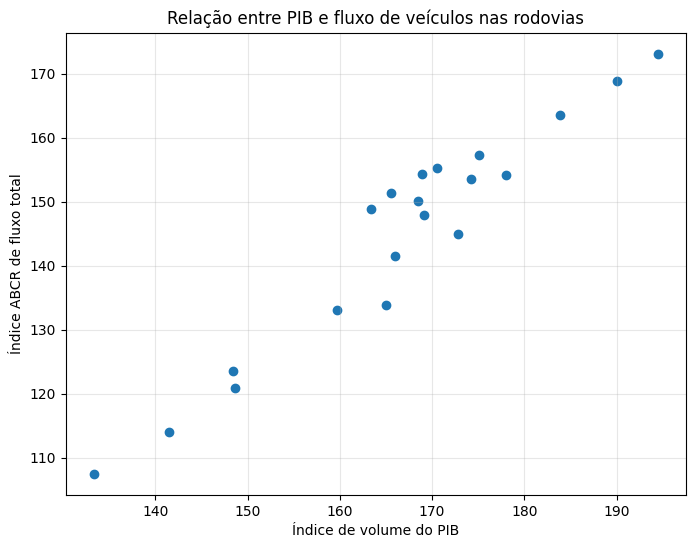

In [35]:
plt.figure(figsize=(8, 6))

plt.scatter(
    base_final["PIB_indice"],
    base_final["ABCR_indice"]
)

plt.xlabel("Índice de volume do PIB")
plt.ylabel("Índice ABCR de fluxo total")
plt.title("Relação entre PIB e fluxo de veículos nas rodovias")
plt.grid(True, alpha=0.3)

plt.show()

In [36]:
correlacao = base_final["PIB_indice"].corr(
    base_final["ABCR_indice"]
)

print(f"Correlação de Pearson: {correlacao:.4f}")

Correlação de Pearson: 0.9641


### Análise da correlação

A correlação de Pearson entre o índice de volume do PIB e o Índice ABCR de fluxo total de veículos foi de aproximadamente 0,964.

O valor é positivo e próximo de 1, indicando uma associação linear positiva muito forte entre as duas variáveis no período de 2006 a 2025. Em geral, anos com maior índice de volume do PIB também apresentam maior índice ABCR.

Entretanto, a correlação não demonstra uma relação de causa e efeito. Portanto, não é possível concluir apenas com essa análise que as variações do PIB causam as variações no fluxo de veículos. Outros fatores econômicos e estruturais também podem influenciar o fluxo rodoviário.

In [38]:
X = base_final[["PIB_indice"]]
y = base_final["ABCR_indice"]

In [39]:
base_final[["PIB_indice"]]

,PIB_indice
0,133.3500
1,141.4475
2,148.6525
3,148.4675
4,159.6425
5,165.9850
6,169.1750
7,174.2600
8,175.1400
9,168.9275


In [40]:
base_final["ABCR_indice"]

,ABCR_indice
0,107.489722
1,113.985870
2,120.908694
3,123.602071
4,133.120557
5,141.443000
6,147.972044
7,153.589045
8,157.233207
9,154.248226


In [41]:
print("Formato de X:", X.shape)
print("Formato de y:", y.shape)

Formato de X: (20, 1)
Formato de y: (20,)


In [42]:
X_treino = X.iloc[:16]
X_teste = X.iloc[16:]

y_treino = y.iloc[:16]
y_teste = y.iloc[16:]

In [43]:
print("Anos de treinamento:")
print(base_final.iloc[:16]["Ano"].tolist())

print("\nAnos de teste:")
print(base_final.iloc[16:]["Ano"].tolist())

Anos de treinamento:
[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

Anos de teste:
[2022, 2023, 2024, 2025]


In [44]:
modelo = LinearRegression()

In [45]:
modelo.fit(X_treino, y_treino)

LinearRegression()

In [46]:
print("Coeficiente angular:", modelo.coef_[0])
print("Intercepto:", modelo.intercept_)

Coeficiente angular: 1.2145325765595785
Intercepto: -56.785599671489564


In [47]:
y_previsao = modelo.predict(X_teste)

print(y_previsao)

[159.45888925 166.46674222 174.10007946 179.38025984]


In [48]:
resultado_teste = pd.DataFrame({
    "Ano": base_final.iloc[16:]["Ano"].values,
    "ABCR_observado": y_teste.values,
    "ABCR_previsto": y_previsao
})

resultado_teste

,Ano,ABCR_observado,ABCR_previsto
0,2022,154.123495,159.458889
1,2023,163.490795,166.466742
2,2024,168.875807,174.100079
3,2025,173.120446,179.380260


## MAE

In [49]:
mae = mean_absolute_error(y_teste, y_previsao)

print(f"MAE: {mae:.4f}")

MAE: 4.9489


## MSE

In [50]:
mse = mean_squared_error(y_teste, y_previsao)

print(f"MSE: {mse:.4f}")

MSE: 25.9502


## R²

In [51]:
r2 = r2_score(y_teste, y_previsao)

print(f"R²: {r2:.4f}")

R²: 0.4849


## Tabela das métricas

In [52]:
metricas = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "R²"],
    "Valor": [mae, mse, r2]
})

metricas["Valor"] = metricas["Valor"].round(4)

metricas

,Métrica,Valor
0,MAE,4.9489
1,MSE,25.9502
2,R²,0.4849


## Gráfico

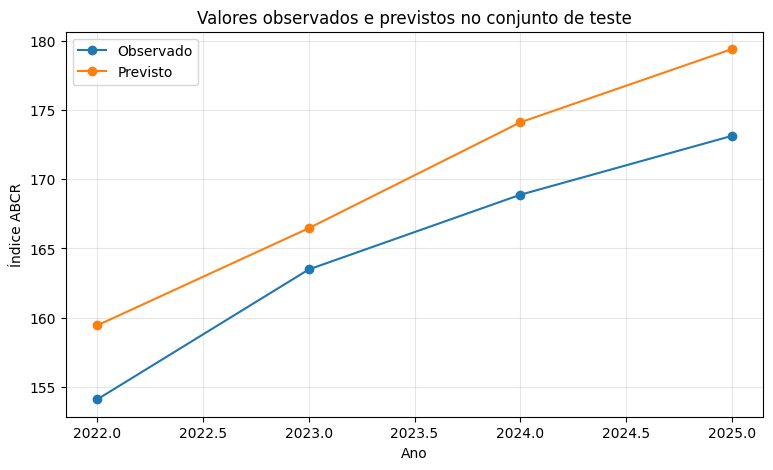

In [53]:
plt.figure(figsize=(9, 5))

plt.plot(
    resultado_teste["Ano"],
    resultado_teste["ABCR_observado"],
    marker="o",
    label="Observado"
)

plt.plot(
    resultado_teste["Ano"],
    resultado_teste["ABCR_previsto"],
    marker="o",
    label="Previsto"
)

plt.xlabel("Ano")
plt.ylabel("Índice ABCR")
plt.title("Valores observados e previstos no conjunto de teste")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Avaliação do modelo

O modelo de regressão linear foi treinado com os primeiros 16 anos da série, de 2006 a 2021, mantendo a ordem cronológica dos dados. Os quatro anos seguintes, de 2022 a 2025, foram utilizados exclusivamente para teste.

O modelo apresentou MAE de aproximadamente 4,95 e MSE de aproximadamente 25,95. Isso significa que, no conjunto de teste, as previsões apresentaram um erro absoluto médio de cerca de 4,95 pontos do Índice ABCR.

O R² obtido foi aproximadamente 0,485. Portanto, no conjunto de teste, o modelo explicou cerca de 48,5% da variação observada no Índice ABCR.

Comparando os valores observados e previstos, percebe-se que o modelo apresentou uma tendência de superestimar o fluxo de veículos nos quatro anos do teste. As previsões ficaram relativamente próximas dos valores observados, mas ainda apresentaram diferenças relevantes.

Assim, a regressão linear encontrou uma relação positiva entre o índice de volume do PIB e o Índice ABCR, mas a capacidade de previsão fora da amostra utilizada no treinamento foi apenas moderada.

É importante destacar que uma correlação elevada entre PIB e ABCR não demonstra, por si só, uma relação de causa e efeito. A atividade econômica e o fluxo de veículos podem estar relacionados a outros fatores que não foram incluídos no modelo.

## Fontes:

https://melhoresrodovias.org.br/indice-abcr_2/
https://sidra.ibge.gov.br/tabela/1620#resultado